# Clase 7 — El procedimiento estándar de Machine Learning

En la clase 6 construimos el mapa conceptual: qué es ML, para qué sirve, qué familias de algoritmos existen, qué problemas resuelven y qué riesgos conllevan.

Hoy vamos a ver el **procedimiento estándar**: el flujo que repite casi cualquier proyecto de ML, desde el primer día hasta el día en que el sistema se pone en producción. Este procedimiento vale para clasificación, regresión, detección de anomalías y cualquier otra tarea.

No vamos a código todavía. Vamos a entender **qué** se hace, **por qué** se hace, **en qué orden** y qué decisiones en cada paso impactan el resultado. Al final, un ejercicio tutorial paso a paso te muestra cómo se ve en la práctica.

## Contenido

| Sección | Tema |
|---|---|
| 1 | De problema real a dataset |
| 2 | Definir features, target y unidad de observación |
| 3 | Separar datos en entrenamiento y prueba |
| 4 | Preprocesamiento: por qué y qué tipos |
| 5 | Seleccionar y entrenar un modelo |
| 6 | Evaluar con métricas básicas |
| 7 | Reproducibilidad: el rol del Pipeline |
| 8 | Decisiones técnicas que impactan el resultado |
| 9 | Ejercicio tutorial: predicción de precio de casas |

---
## 1. De problema real a dataset

Machine Learning comienza con un problema real. Alguien en una institución o empresa dice: "Nos cuesta tiempo y recursos decidir sobre estos casos. ¿Podemos automatizar o mejorar cómo los clasificamos/evaluamos/priorizamos?"

Ejemplos concretos:

| Institución | Problema | Pregunta ML |
|---|---|---|
| Centro de atención al ciudadano | Hay demasiadas consultas entrantes para derivar manualmente | ¿A qué área pertenece cada consulta? |
| Hospital | No se sabe de antemano quién necesita cuidados intensivos | ¿Qué pacientes tienen mayor riesgo? |
| Escuela | Se pierden estudiantes sin saber quién está en riesgo | ¿Qué estudiantes necesitan acompañamiento temprano? |
| Banco | Hay fraude pero es difícil detectarlo manualmente | ¿Qué operaciones son sospechosas? |
| Municipalidad | Los reclamos se amontonan sin prioridad clara | ¿Qué reclamos son más urgentes? |

El salto de "problema" a "dataset" requiere dos decisiones humanas clave:

**Decisión 1: definir la tarea con precisión**

No es suficiente decir "clasificar". Hay que especificar:
- ¿Qué decisión exacta queremos apoyar?
- ¿Qué información tendremos disponible en el momento de predecir?
- ¿Quién usará las predicciones y cómo?

**Decisión 2: identificar datos históricos**

Hay que preguntar:
- ¿Tenemos casos históricos resueltos?
- ¿Quién etiquetó o decidió en esos casos?
- ¿Esos datos están documentados y accesibles?
- ¿Son representativos del problema futuro?

Ejemplo: si un hospital quiere predecir riesgo de reingreso, necesita historiales de pacientes que ya fueron dados de alta y seguimiento sobre quiénes reinternaron. Sin esos datos históricos, no hay ML posible.

---
## 2. Definir features, target y unidad de observación

Un dataset es una tabla donde cada fila es un caso y cada columna es una variable. Para un proyecto de ML necesitamos tres tipos de columnas:

| Concepto | Qué es | Ejemplo |
|---|---|---|
| **Unidad de observación** | Qué representa cada fila | Una consulta, un paciente, un estudiante, una transacción |
| **Features** | Información disponible sobre cada caso | Texto de la consulta, edad del paciente, horas de estudio |
| **Target / Etiqueta** | Qué queremos predecir | Categoría de la consulta, riesgo (alto/bajo), aprobó o no |

### El proceso de decisión

**Definir la unidad de observación** es más importante de lo que parece. Ejemplo:

| Pregunta | Unidad de observación | Features | Target |
|---|---|---|---|
| ¿Qué consultas necesitan escalada? | Una consulta | Texto, hora, usuario | Escalada sí/no |
| ¿Quién va a abandonar? | Un cliente | Histórico de compras, contactos | Abandonó sí/no |
| ¿Qué día habrá mayor demanda? | Un día de la semana | Clima, eventos, día anterior | Demanda (número) |

En cada caso, la misma institución podría responder preguntas muy distintas con unidades de observación distintas.

**Elegir las features** requiere balancear varios criterios:

| Criterio | Pregunta |
|---|---|
| **Disponibilidad** | ¿Tenemos estos datos? ¿Ya están recopilados? |
| **Costo de obtención** | ¿Cuánto esfuerzo implica conseguir o procesar estos datos? |
| **Relevancia lógica** | ¿Tiene sentido que estos datos predigan el target? |
| **Sesgo potencial** | ¿Estas features pueden discriminar injustamente a ciertos grupos? |
| **Cantidad** | ¿Son demasiadas (complejidad, overfitting) o demasiadas pocas (poca información)? |

**Definir el target** con claridad es crucial. El target NO es solo un número; es una decisión humana previa. Ejemplos de decisiones implícitas:

- ¿Consulta "urgente"? Alguien definió qué significa urgente.
- ¿Paciente "de riesgo alto"? Un médico estableció ese umbral.
- ¿Transacción "fraudulenta"? Hubo un proceso de investigación que confirmó el fraude.

Si el criterio del target está borroso o cambia con el tiempo, el modelo entrenado hoy puede quedar obsoleto rápidamente.

### Validación mental antes de empezar

Antes de invertir en código, conviene preguntarse:

1. ¿Las features hacen sentido lógico para predecir el target?
2. ¿Hay suficientes casos históricos etiquetados de forma confiable?
3. ¿El patrón que el modelo aprendería es estable en el tiempo o cambia?
4. ¿Si el modelo se equivoca, quién y cómo se notaría?

---
## 3. Separar datos en entrenamiento y prueba

Un error fundamental en ML es usar los mismos datos para entrenar el modelo y para medir si funciona. Es como estudiar exactamente los ejercicios que van a venir en el examen: la nota alta no te dice si entendiste, solo que memorizaste.

La solución es **dividir el dataset en dos partes antes de empezar**:

| Conjunto | Cuándo se usa | Qué mide |
|---|---|---|
| **Entrenamiento (train)** | Para que el modelo aprenda patrones | No mide nada formal; es la materia prima |
| **Prueba (test)** | Para medir si el modelo funciona en datos nunca vistos | La verdadera capacidad predictiva del modelo |

### Por qué importa el orden

La división tiene que hacerse ANTES de cualquier otra operación. El flujo correcto es:

```
Dataset original
    ↓
DIVIDIR en train/test (aquí y solo aquí)
    ↓
Preprocesar train (aprender parámetros)
    ↓
Entrenar modelo (aprender patrones)
    ↓
Evaluar en test (medir qué tal funciona)
```

Si el orden es distinto — por ejemplo, si escalas primero todo el dataset y luego divides — el test set no es realmente "nunca visto". El scaler ya lo vio cuando aprendió la media y la desviación estándar. Eso se llama **data leakage**: información del futuro (test) se filtra al entrenamiento.

### Proporción y representatividad

Una división típica es 80% train / 20% test. Pero lo más importante es que ambos conjuntos representen el mismo problema:

| Situación | Riesgo | Cómo evitarlo |
|---|---|---|
| El target es muy desbalanceado (p.ej., 95% de casos negativos) | El test podría tener casi puros negativos | Usar `stratify` al dividir |
| Los datos cambian con el tiempo | El test podría no representar datos futuros | Dividir respetando la secuencia temporal |
| Hay casos repetidos o muy similares | El modelo memorizaría | Asegurarse de remover duplicados antes |

### Train y test nunca se tocan

Una vez dividido, el conjunto de test debe ser intocable hasta que termines de tunear el modelo. Si los tocas, empiezas a optimizar para ese test específico en lugar de para el problema general — y vuelve la tentación de overfitting.

---
## 4. Preprocesamiento: por qué y qué tipos

Raramente los datos están listos para entrenar un modelo directamente. El preprocesamiento transforma datos "reales" (con valores faltantes, formatos mixtos, escalas distintas) en datos que un algoritmo pueda procesar.

### Por qué hace falta

| Problema | Consecuencia |
|---|---|
| Valores faltantes (NaN) | El modelo colapsa o produce errores |
| Features con escalas muy distintas (p.ej., edad 0-120 vs. ingreso 0-10M) | El modelo da más peso a las grandes magnitudes sin razón |
| Variables categóricas (texto: "hombre", "mujer") | Los modelos de scikit-learn solo entienden números |
| Outliers extremos | Pueden distorsionar el aprendizaje |
| Duplicados exactos | Inflan artificialmente la data |

### Tipos principales de transformaciones

| Transformación | Qué hace | Ejemplo |
|---|---|---|
| **Imputación** | Reemplaza valores faltantes | Si falta la edad, usar la edad promedio de los casos conocidos |
| **Escalado** | Normaliza la magnitud de features | Convertir edades de 0-120 a 0-1 o a media=0, std=1 |
| **Encoding categórico** | Convierte texto a números | "Hombre" → 1, "Mujer" → 0, o one-hot encoding |
| **Transformación log / potencia** | Cambia la distribución de los datos | Si los datos están muy sesgados, un log puede ayudar |
| **Feature engineering** | Crea nuevas features a partir de existentes | De fecha, extraer el día de la semana; de nombre, extraer longitud |
| **Detección de outliers** | Marca o remueve valores extremos | Si edad = -50 o 200, algo anda mal |

### Decisiones clave en preprocesamiento

| Decisión | Pregunta |
|---|---|
| **Estrategia de imputación** | ¿Usar promedio, mediana, moda, un modelo? ¿O remover filas? |
| **Qué features procesar** | ¿Todas igual? ¿Numéricas y categóricas por separado? |
| **Transformación y escalado** | ¿StandardScaler (media 0, std 1)? ¿MinMaxScaler (0-1)? ¿Ninguno? |
| **Crear o eliminar features** | ¿Tienes features redundantes? ¿Necesitas crear derivadas? |

### Aprendizaje del preprocesador

Punto crítico: **el preprocesador se "entrena" con el conjunto de train solamente**. Ejemplo:

- Se calcula la media de edad del train.
- Se aplica esa media para imputar valores en train y en test.
- NO se recalcula la media cuando se ve el test.

Esto es similar al modelo: aprende de train, predice en test sin "ver" el test. Si lo hicieras distinto, estarías filtrando información del test hacia el entrenamiento.

---
## 5. Seleccionar y entrenar un modelo

Una vez que los datos están listos, hay que elegir un algoritmo y entrenarlo. Esta es la parte que recibe toda la atención en tutoriales de ML, pero en realidad ocupa menos del 20% del trabajo real.

### Seleccionar el algoritmo

La decisión depende de:

| Factor | Pregunta | Opciones |
|---|---|---|
| **Tipo de tarea** | ¿Es clasificación, regresión, clustering? | Clasificación: KNN, árbol, regresión logística, SVM, ... |
| **Cantidad de datos** | ¿Tienes 100 casos o 100 millones? | Con pocos datos: modelos simples; con muchos: deep learning |
| **Interpretabilidad** | ¿Necesitas explicar por qué decidió así? | Árbol de decisión, regresión: interpretables; redes neuronales: opacas |
| **Velocidad** | ¿La predicción debe ser instantánea? | KNN es lento; regresión es rápido |
| **Complejidad del patrón** | ¿Hay relaciones lineales o muy no-lineales? | Lineal: regresión; no-lineal: árbol, ensemble, redes |
| **Memoria y almacenamiento** | ¿Qué recursos tenés disponibles? | Redes neuronales grandes necesitan GPU |

En la clase 6 vimos familias de algoritmos. Hoy enfatizamos que **no hay un algoritmo "mejor" universalmente**. El mejor es el que funciona para tu problema específico.

### Entrenar el modelo

El entrenamiento es un proceso automático donde el algoritmo ajusta sus parámetros internos buscando minimizar un error:

```
Modelo inicial (parámetros al azar)
    ↓
Procesar caso del train, medir error
    ↓
Ajustar parámetros para reducir ese error
    ↓
Repetir con todos los casos del train
    ↓
(Opcionalmente, repetir varias veces toda la secuencia)
    ↓
Modelo entrenado
```

El resultado es un modelo que ha visto los patrones en train y aprendió a reconocerlos. Pero no sabemos aún si va a funcionar en datos nuevos — eso lo medimos después.

### Riesgo: overfitting

Entrenar demasiado, con demasiada complejidad, puede llevar a que el modelo **memorice** los datos de train en lugar de aprender patrones generales. En train tiene accuracy alta, pero en test falla.

| Causa | Señal | Cómo evitarlo |
|---|---|---|
| Modelo muy complejo para pocos datos | Accuracy train=99%, test=60% | Usar modelos más simples, más datos, regularización |
| Entrenamiento demasiado largo | El error en train sigue bajando pero en validación sube | Detener el entrenamiento antes |
| Features redundantes o ruidosas | El modelo usa patrones irrelevantes | Seleccionar features, remover ruido |

Por eso es importante medir en un conjunto separado (test) desde el inicio.

---
## 6. Evaluar con métricas básicas

Una vez entrenado, el modelo se prueba en datos que nunca vio (el conjunto test) para medir si realmente funciona.

### Métricas para clasificación

En la clase 8 profundizaremos. Por ahora, lo importante es entender que "accuracy" (% de aciertos) no siempre es suficiente:

| Métrica | Qué mide | Cuándo usarla |
|---|---|---|
| **Accuracy** | % de predicciones correctas | Cuando los errores de cada tipo son igual de costosos |
| **Precision** | De los que predije "sí", ¿cuántos eran realmente sí? | Cuando un falso positivo es caro (p.ej., alertas falsas) |
| **Recall** | De todos los reales "sí", ¿cuántos detecté? | Cuando un falso negativo es caro (p.ej., no detectar fraude) |
| **F1** | Balance entre precision y recall | Cuando ambos errores importan |
| **Matriz de confusión** | Desglose de verdaderos positivos, falsos positivos, etc. | Para entender qué tipo de error está cometiendo |

### Interpretación de resultados

| Resultado | Interpre tación | Siguiente paso |
|---|---|---|
| Accuracy del 95% en test | Promisorio | Medir otras métricas, revisar casos de error |
| Accuracy en train=99%, en test=65% | Overfitting | Simplificar el modelo, obtener más datos |
| Accuracy en train=65%, en test=63% | Underfitting | Usar modelo más complejo, agregar features |
| Métricas muy distintas por clase | Datos desbalanceados | Usar stratification, resampling, pesos de clase |

### Decisiones después de la evaluación

Si el modelo funciona bien:
- Guardarlo y ponerlo en producción.
- Planificar monitoreo para detectar si envejece.

Si no funciona:
- ¿Falta data? Reunir más casos.
- ¿Faltan features relevantes? Consultar con expertos del dominio.
- ¿El patrón es muy complejo? Probar algoritmo más sofisticado.
- ¿Hay calidad de etiquetas? Revisar cómo se etiquetó el dataset.
- ¿El problema es imposible? A veces los datos no tienen el patrón que buscamos.

---
## 7. Reproducibilidad: el rol del Pipeline

Un proyecto de ML que funciona hoy puede ser caótico en seis meses si no está documentado. El `Pipeline` (tubería) es una herramienta que resuelve esto: encadena preprocesamiento, selección de features y modelo en un único objeto.

### El problema sin Pipeline

Imagina que entrenaste un modelo así:

1. Cargas datos desde CSV.
2. Calculas la media de edad y escalas.
3. Imputas valores faltantes.
4. Eliminas columnas ruidosas.
5. Entrenas un modelo.

Hoy funciona. En seis meses, cuando alguien pida una predicción nueva, ¿recuerda los pasos exactos? ¿El orden? ¿Los parámetros? Probablemente no. Y si alguien intenta replicar el experimento en otro equipo, casi seguro se pierde.

### La solución: Pipeline

Un Pipeline encadena las transformaciones y el modelo:

```
Pipeline(
    pasos=[
        ("imputar", SimpleImputer),
        ("escalar", StandardScaler),
        ("modelo", LogisticRegression)
    ]
)
```

Ventajas:

| Ventaja | Beneficio |
|---|---|
| **Código declarativo** | El flujo queda documentado explícitamente |
| **Aplicación consistente** | Cada paso se aplica siempre en el mismo orden |
| **Prevención de data leakage** | Cada transformador "aprende" solo con train |
| **Reutilización** | Podes guardar el pipeline entrenado y usarlo después |
| **Escalabilidad** | Funciona igual si el dataset crece 10x |

### Flujo típico con Pipeline

```
Pipeline.fit(X_train, y_train)
    → Aprende parámetros de train
    → Entrena el modelo con esos datos

Pipeline.predict(X_test)
    → Aplica las transformaciones aprendidas en train
    → Produce predicciones
    → Sin volver a aprender nada del test

Pipeline.predict(X_nuevo)
    → Aplica las transformaciones
    → Produce predicciones
    → Puede guardarse y compartirse
```

El Pipeline es la forma estándar de asegurar reproducibilidad: cualquiera que tenga el pipeline guardado puede producir exactamente las mismas predicciones sin tener que recordar ni documentar manualmente cada paso.

---
## 8. Decisiones técnicas que impactan el resultado

A lo largo de este flujo, cada decisión modifica el resultado final. Entender cuáles son las más críticas te ayuda a saber dónde enfocarte.

### Las decisiones de mayor impacto (de mayor a menor)

| Decisión | Impacto | Ejemplo |
|---|---|---|
| **Calidad de etiquetas** | 🔴 Crítico | Si el target está mal etiquetado, el modelo está condenado |
| **Features relevantes** | 🔴 Crítico | Si usas features que no predice nada, el modelo fracasa |
| **Cantidad de datos** | 🟠 Alto | Con 50 casos es difícil aprender; con 50k es más fácil |
| **Algoritmo elegido** | 🟠 Alto | Árbol para un problema lineal puede ser overkill |
| **Hiperparámetros** | 🟡 Medio | Cambiar learning_rate o max_depth afecta, pero no es lo principal |
| **Escala de features** | 🟡 Medio | Escalar mejora algunos algoritmos pero no todos |
| **División train/test** | 🟡 Medio | Si la proporción es muy desbalanceada, afecta |
| **Semilla aleatoria** | 🟢 Bajo | Para reproducibilidad, pero no cambia el resultado significativamente |

### Donde invertir esfuerzo

Si tienes poco tiempo:
1. **Primero:** Asegúrate de que las etiquetas están bien.
2. **Segundo:** Entiende qué features son realmente predictivas.
3. **Tercero:** Reúne más datos si es posible.
4. **Cuarto:** Prueba distintos algoritmos simples.
5. **Al final:** Afina hiperparámetros.

La tentación es saltarse los primeros pasos e ir directo a afinar hiperparámetros. Eso es como intentar optimizar el motor de un auto que no tiene ruedas.

### La iteración es normal

Casi nunca funciona a la primera:

```
Intento 1: Accuracy 65%
    ↓ (¿Por qué?)
    ↓ Investigo: falta una feature importante
    ↓
Intento 2: Accuracy 78%
    ↓ (¿Por qué no más?)
    ↓ Investigo: hay 30% de valores nulos
    ↓
Intento 3: Accuracy 85%
    ↓ (¿Por qué no más?)
    ↓ Investigo: el modelo está overfitteado
    ↓
Intento 4: Accuracy 82%, pero estable
    ✓ Bueno. Pasamos a producción.
```

Esta iteración es normal y esperada. Cada ciclo te enseña algo sobre el problema.

---
## 9. Tutorial: aplicar el procedimiento a un caso real

Toda la teoría anterior se resume en este flujo paso a paso. No es un ejercicio para completar; es un tutorial que verás ejecutado para que entiendas cómo se ve el procedimiento en código.

El caso: predecir si una casa tiene precio **por encima o por debajo de la mediana del mercado**, a partir de sus características físicas y de ubicación.

Este caso es especialmente útil porque:
- Los datos hacen sentido intuitivo para cualquiera.
- Las features tienen relación lógica clara con el precio.
- Podés discutir qué errores son más graves en distintos contextos (comprador vs. vendedor vs. tasador).
- Es uno de los ejemplos más usados en el mundo real para introducir ML.

**Seguí cada paso del procedimiento que vimos en las secciones anteriores.**

### Paso 1: Preparar el dataset

Cargamos librerías y creamos un dataset simulado de propiedades. En un proyecto real, este dataset vendría de registros de ventas históricas.

Abrir la terminal de VSCODE y ejecutar:

```pip install seaborn``` 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
n = 300

# Crear dataset simulado de propiedades
df_casas = pd.DataFrame({
    "superficie_m2":      np.random.normal(120, 50, n).clip(30, 400),
    "habitaciones":       np.random.randint(1, 7, n).astype(float),
    "banos":              np.random.randint(1, 5, n).astype(float),
    "antiguedad_anos":    np.random.randint(0, 51, n).astype(float),
    "distancia_centro_km": np.random.exponential(8, n).clip(0.5, 40),
    "calidad_barrio":     np.random.randint(1, 11, n).astype(float),
})

# Introducir valores faltantes (realismo)
df_casas.loc[np.random.choice(n, 15, replace=False), "calidad_barrio"] = np.nan
df_casas.loc[np.random.choice(n, 10, replace=False), "antiguedad_anos"] = np.nan

# Crear target: precio alto (1) si está por encima de la mediana simulada
precio_latente = (
    0.40 * (df_casas["superficie_m2"] / 400) +
    0.20 * (df_casas["calidad_barrio"].fillna(5) / 10) +
    0.15 * (df_casas["habitaciones"] / 6) +
    0.10 * (df_casas["banos"] / 4) +
    0.10 * (1 - df_casas["distancia_centro_km"] / 40) +
    0.05 * (1 - df_casas["antiguedad_anos"].fillna(25) / 50)
) + np.random.normal(0, 0.06, n)

df_casas["precio_alto"] = (precio_latente > precio_latente.median()).astype(int)

print("Dataset cargado:")
print(f"  Tamaño: {df_casas.shape}")
print(f"  Proporción precio alto: {df_casas['precio_alto'].mean():.1%}")
print(f"  Valores faltantes por columna:\n{df_casas.isnull().sum()}")
print("\nPrimeras filas:")
df_casas.head()

Dataset cargado:
  Tamaño: (300, 7)
  Proporción precio alto: 50.0%
  Valores faltantes por columna:
superficie_m2           0
habitaciones            0
banos                   0
antiguedad_anos        10
distancia_centro_km     0
calidad_barrio         15
precio_alto             0
dtype: int64

Primeras filas:


,superficie_m2,habitaciones,banos,antiguedad_anos,distancia_centro_km,calidad_barrio,precio_alto
0,144.835708,1.0,1.0,29.0,4.213088,7.0,0
1,113.086785,4.0,4.0,34.0,6.424539,4.0,1
2,152.384427,2.0,4.0,20.0,4.583403,2.0,0
3,196.151493,5.0,4.0,36.0,2.790400,4.0,1
4,108.292331,1.0,1.0,4.0,23.722138,6.0,0


### Pasos 2-7: Aplicar el procedimiento completo

Aquí vemos cómo encadena cada paso: separar datos, preprocesar y entrenar el modelo usando un Pipeline.

In [2]:
# Paso 2: Definir features y target
features = ["superficie_m2", "habitaciones", "banos", "antiguedad_anos",
            "distancia_centro_km", "calidad_barrio"]
X = df_casas[features]
y = df_casas["precio_alto"]

# Paso 3: Separar en train (80%) y test (20%)
# stratify=y asegura que ambos conjuntos tengan la misma proporción de precios altos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Paso 3 — Separación de datos:")
print(f"  Train: {X_train.shape[0]} casos")
print(f"  Test:  {X_test.shape[0]} casos")
print(f"  Proporción precio alto en train: {y_train.mean():.1%}")
print(f"  Proporción precio alto en test:  {y_test.mean():.1%}")
print()

# Pasos 4-7: Construir, entrenar y evaluar el Pipeline
pipeline = Pipeline(steps=[
    ("imputar",  SimpleImputer(strategy="median")),
    ("escalar",  StandardScaler()),
    ("modelo",   LogisticRegression(max_iter=500, random_state=42)),
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Paso 7 — Resultados de evaluación:")
print(f"  Accuracy en test: {accuracy:.2%}")
print()
print("  Matriz de confusión:")
print(f"    Verdadero Negativo (TN):  {cm[0, 0]}")
print(f"    Falso Positivo (FP):      {cm[0, 1]}")
print(f"    Falso Negativo (FN):      {cm[1, 0]}")
print(f"    Verdadero Positivo (TP):  {cm[1, 1]}")
print()
print("  Reporte completo:")
print(classification_report(y_test, y_pred, target_names=["Precio bajo", "Precio alto"]))

Paso 3 — Separación de datos:
  Train: 240 casos
  Test:  60 casos
  Proporción precio alto en train: 50.0%
  Proporción precio alto en test:  50.0%

Paso 7 — Resultados de evaluación:
  Accuracy en test: 88.33%

  Matriz de confusión:
    Verdadero Negativo (TN):  28
    Falso Positivo (FP):      2
    Falso Negativo (FN):      5
    Verdadero Positivo (TP):  25

  Reporte completo:
              precision    recall  f1-score   support

 Precio bajo       0.85      0.93      0.89        30
 Precio alto       0.93      0.83      0.88        30

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



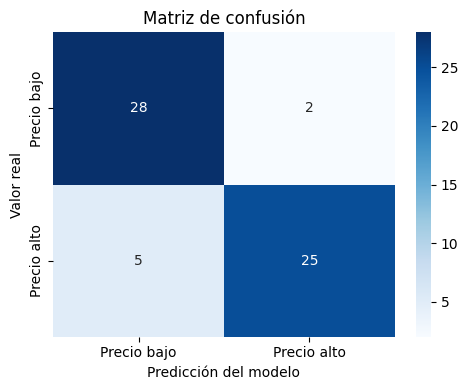

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Precio bajo", "Precio alto"],
    yticklabels=["Precio bajo", "Precio alto"],
    ax=ax
)
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Valor real")
ax.set_title("Matriz de confusión")
plt.tight_layout()
plt.show()

### Reflexión: decisiones técnicas en contexto

Ahora que viste el flujo ejecutado, reflexionemos sobre decisiones que afectan el resultado:

**Pregunta 1 — Sobre los datos y features**

Mirando la matriz de confusión: ¿qué tipo de error es más común? ¿Predice mejor "precio alto" o "precio bajo"? ¿Por qué podría ser?

**Pregunta 2 — Sobre el contexto**

¿Qué significa un **falso positivo** en este contexto? Es decir, el modelo predice "precio alto" para una casa que en realidad tiene precio bajo. ¿A quién le perjudica ese error? ¿Al comprador? ¿Al vendedor? ¿A la tasadora?

¿Qué significa un **falso negativo**? El modelo predice "precio bajo" para una casa que en realidad vale más. ¿Quién pierde en ese caso?

**Pregunta 3 — Sobre las decisiones de impacto**

¿Habría sucedido algo distinto si:
- Hubieran usado `test_size=0.5` en lugar de `0.2` para la división?
- Hubieran escalado ANTES de dividir train/test?
- Hubieran removido `calidad_barrio` porque tiene valores faltantes?
- Hubieran usado un árbol de decisión en lugar de regresión logística?

**Pregunta 4 — Sobre reproducibilidad**

¿Por qué es importante que el Pipeline guarde el scaler entrenado? ¿Qué pasaría si para cada predicción nueva aprendieras un scaler nuevo desde cero?